# Multistage Knowledge Distillation — Breast Ultrasound Dual-Task
## Teacher: DINOv2 ViT-B/14 &nbsp;→&nbsp; Student: MobileNetV2-small + SMP UNet
### Dataset: BUSI | Tasks: Binary Segmentation + 3-Class Classification

---
**Three-phase pipeline (run sequentially in a single session):**

| Phase | Model | Purpose |
|-------|-------|---------|
| 1 | Teacher — DINOv2 ViT-B/14 (87.5 M) | Establish teacher baseline |
| 2 | Student — MobileNetV2-small + SMP UNet (~3.4 M) | Establish student baseline (no KD) |
| 3 | Student (fresh init) + MSKD | Multistage distillation |

**MSKD Stage Schedule:**

| Stage | Epochs | Active Losses | Notes |
|-------|--------|--------------|-------|
| 1 — Warm-up | 1–5 | Task only | Student initialises stable gradients |
| 2 — Response KD | 6–25 | Task + KL(cls) + MSE(seg) | Hinton soft-label + pixel-level transfer |
| 3 — Feature KD | 26–50 | + Cosine(feat) | Encoder embedding alignment |
| 4 — Refinement | 51–60 | Task-dominant, light KD | Fine-tune toward task objective |

> **Evaluation fairness**: all three models are tested on the **same test split** using the **same test loader** (batch=16, no augmentation) so every metric is directly comparable.


In [1]:
# Kaggle already ships transformers, smp, albumentations, timm.
# Uncomment if running elsewhere:
# !pip install transformers segmentation-models-pytorch albumentations timm -q
import subprocess, sys
for pkg in ["transformers","segmentation_models_pytorch","albumentations","timm"]:
    try: __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable,"-m","pip","install",
                               pkg.replace("_","-"),"-q"])
print("All packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.1 MB/s eta 0:00:00
All packages ready.


## 1. Imports & Configuration

In [2]:
import os, re, gc, time, warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import albumentations as A
import segmentation_models_pytorch as smp
from transformers import Dinov2Model
from tqdm import tqdm

warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [3]:
# ─── Paths ───────────────────────────────────────────────────────────────────
# Adjust DATA_ROOT to match the name of your Kaggle dataset input.
# Two common BUSI layouts are supported (see build_dataframe below).
DATA_ROOT = Path("/kaggle/input/datasets/arittrodhrubo03/breast-lesion-segmentation-dt1/combined_dataset")
# DATA_ROOT = Path("/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT")
CKPT_DIR  = Path("/kaggle/working/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ─── Teacher config — identical to best-performing model ─────────────────────
TCFG = {
    "img_size":       322,      # 322 = 23 × 14  (DINOv2 patch_size=14)
    "patch_size":     14,
    "batch_size":     8,
    "epochs":         60,
    "lr":             1e-4,     # classification & seg-decoder head LR
    "encoder_lr":     1e-5,     # backbone gets 10× smaller LR
    "weight_decay":   1e-4,
    "num_workers":    2,
    "dino_model":     "facebook/dinov2-base",
    "num_classes":    3,
    "cls_weight":     0.4,      # total_loss = seg_loss + cls_weight * cls_loss
    "threshold":      0.5,
    "warmup_epochs":  5,        # freeze backbone for first 5 epochs
    "patience":       10,       # early stopping patience (epochs with no val Dice improvement)
}

# ─── Student config ───────────────────────────────────────────────────────────
SCFG = {
    "img_size":       322,
    "batch_size":     16,
    "epochs":         60,
    "lr":             1e-4,         # FIX: smaller LR for pretrained encoder
    "weight_decay":   1e-4,
    "num_workers":    2,
    "encoder_name":   "mobilenet_v2",
    "encoder_weights": "imagenet",  # FIX: ImageNet pretrained — essential on small datasets
    "num_classes":    3,
    "cls_weight":     0.4,
    "threshold":      0.5,
    "patience":       12,
    "encoder_lr":    5e-5,        # FIX: encoder gets 5× smaller LR (differential)
}

# ─── MSKD config ─────────────────────────────────────────────────────────────
MCFG = {
    "epochs":         80,
    "batch_size":     16,
    "lr":             2e-4,
    "weight_decay":   1e-4,
    "num_workers":    2,
    "temperature":    4.0,          # FIX: T=4.0 — softer targets carry more dark knowledge; T=2.0 was barely different from hard labels
    "s1_end":  5,   "s2_end":  25,
    "s3_end":  50,  "s4_end":  60,
    "patience":       12,       # early stopping patience per stage — increased for weaker student
    "stages": {
        1: dict(task=1.0, cls_kd=0.0, seg_kd=0.0, feat_kd=0.0),
        2: dict(task=0.7, cls_kd=0.3, seg_kd=0.4, feat_kd=0.0),   # FIX: seg_kd 1.2→0.4 prevents imperfect teacher masks drowning task signal
        3: dict(task=0.6, cls_kd=0.2, seg_kd=0.3, feat_kd=0.8),   # FIX: seg_kd 1.0→0.3; feat_kd kept strong; cls_kd raised
        4: dict(task=0.9, cls_kd=0.1, seg_kd=0.1, feat_kd=0.1),   # FIX: refinement fully task-dominant; light KD regularisation only
    },
}

LABEL2IDX  = {"benign": 0, "malignant": 1, "normal": 2}
IDX2LABEL  = {v: k for k, v in LABEL2IDX.items()}
PATCH_GRID = TCFG["img_size"] // TCFG["patch_size"]   # 23
N_PATCHES  = PATCH_GRID ** 2                           # 529
print(f"Teacher patch grid : {PATCH_GRID}x{PATCH_GRID} = {N_PATCHES} patches")
print(f"Teacher batch size : {TCFG['batch_size']}  |  Student batch size : {SCFG['batch_size']}")


Teacher patch grid : 23x23 = 529 patches
Teacher batch size : 8  |  Student batch size : 16


## 2. Dataset

In [4]:
def build_dataframe(root: Path) -> pd.DataFrame:
    """
    Handles two BUSI directory layouts:
      Layout A — root/class/images/*.png  +  root/class/masks/*.png
      Layout B — root/class/*.png  (masks share folder, suffix _mask)
    """
    rows = []
    for cls in ["benign", "malignant", "normal"]:
        cls_dir  = root / cls
        if not cls_dir.exists():
            continue
        img_dir  = cls_dir / "images"
        mask_dir = cls_dir / "masks"

        if img_dir.exists():                       # Layout A
            masks = {re.sub(r"_mask$","",p.stem): str(p)
                     for p in mask_dir.glob("*.png")} if mask_dir.exists() else {}
            for p in sorted(img_dir.glob("*.png")):
                rows.append(dict(image_path=str(p), mask_path=masks.get(p.stem),
                                 label=cls, label_idx=LABEL2IDX[cls]))
        else:                                      # Layout B
            all_png    = sorted(cls_dir.glob("*.png"))
            imgs       = [p for p in all_png if "_mask" not in p.stem]
            mask_idx   = {re.sub(r"_mask$","",p.stem): str(p)
                          for p in all_png if "_mask" in p.stem}
            for p in imgs:
                rows.append(dict(image_path=str(p), mask_path=mask_idx.get(p.stem),
                                 label=cls, label_idx=LABEL2IDX[cls]))
    return pd.DataFrame(rows)


df = build_dataframe(DATA_ROOT)
print(df["label"].value_counts())
print(f"Total: {len(df)} | With mask: {df['mask_path'].notna().sum()}")

train_df, temp_df = train_test_split(df,      test_size=0.30, random_state=42, stratify=df["label"])
valid_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df["label"])
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {len(train_df)} | Valid: {len(valid_df)} | Test: {len(test_df)}")


label
normal       729
benign       477
malignant    261
Name: count, dtype: int64
Total: 1467 | With mask: 1467
Train: 1026 | Valid: 220 | Test: 221


## 3. Augmentation & Dataset Class

In [5]:
IMGNET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMGNET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# ── Albumentations compatibility (GaussNoise API changed in v2.0) ─────────────
import albumentations as _A
_ALB_VER = tuple(int(x) for x in _A.__version__.split(".")[:2])
def _gauss_noise(p=0.2):
    if _ALB_VER >= (2, 0):
        return A.GaussNoise(std_range=(0.05, 0.15), p=p)
    return A.GaussNoise(var_limit=(10.0, 50.0), p=p)

def make_transforms(img_size: int, augment: bool) -> A.Compose:
    base = [A.Resize(img_size, img_size)]
    aug  = [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10,
                           rotate_limit=15, border_mode=cv2.BORDER_CONSTANT, p=0.5),
        A.ElasticTransform(p=0.3),
        A.GridDistortion(p=0.3),
        A.RandomBrightnessContrast(p=0.4),
        A.GaussianBlur(p=0.2),
        _gauss_noise(p=0.2),
    ] if augment else []
    return A.Compose(base + aug)


class BUSIDataset(Dataset):
    """Unified dataset: grayscale -> 3-channel, ImageNet-normalised, same for teacher & student."""
    def __init__(self, df, img_size=322, transforms=None):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.transforms = transforms

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(row["image_path"])
        mp = row["mask_path"]
        if mp and Path(mp).exists():
            msk = (cv2.imread(mp, cv2.IMREAD_GRAYSCALE) > 0).astype(np.float32)
        else:
            msk = np.zeros(img.shape, dtype=np.float32)
        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        msk = cv2.resize(msk, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        if self.transforms:
            out = self.transforms(image=img, mask=msk)
            img, msk = out["image"], out["mask"]
        img = img.astype(np.float32) / 255.0
        img = np.stack([img, img, img], axis=-1)        # grayscale -> 3-channel (required by DINOv2)
        img = (img - IMGNET_MEAN) / IMGNET_STD          # ImageNet normalisation
        img = np.transpose(img, (2, 0, 1))              # HWC -> CHW
        msk = np.expand_dims(msk.astype(np.float32), 0)
        return {
            "image":     torch.tensor(img, dtype=torch.float32),
            "mask":      torch.tensor(msk, dtype=torch.float32),
            "label":     row["label"],
            "label_idx": torch.tensor(row["label_idx"], dtype=torch.long),
        }


def make_loaders(img_size, batch_size, num_workers=2, augment=True):
    tr_ds = BUSIDataset(train_df, img_size, make_transforms(img_size, augment))
    vl_ds = BUSIDataset(valid_df, img_size, make_transforms(img_size, False))
    ts_ds = BUSIDataset(test_df,  img_size, make_transforms(img_size, False))
    kw    = dict(num_workers=num_workers, pin_memory=True)
    tr_ld = DataLoader(tr_ds, batch_size, shuffle=True,  **kw)
    vl_ld = DataLoader(vl_ds, batch_size, shuffle=False, **kw)
    ts_ld = DataLoader(ts_ds, batch_size, shuffle=False, **kw)
    print(f"  train={len(tr_ds)} | valid={len(vl_ds)} | test={len(ts_ds)}")
    return tr_ld, vl_ld, ts_ld, tr_ds, vl_ds, ts_ds

# ── Shared fair-comparison test loader (batch=16, no aug) ─────────────────────
# All three models are evaluated on this IDENTICAL loader — guarantees fair comparison.
_, _, ts_ld_eval, _, _, ts_ds_eval = make_loaders(TCFG["img_size"], 16, augment=False)
print("Shared evaluation loader ready.")


  train=1026 | valid=220 | test=221
Shared evaluation loader ready.


## 4. Models
### 4.1 Teacher Model — DINOv2 ViT-B/14 Dual-Task
Exact architecture and hyperparameters from the best-performing model.

In [6]:
class SegDecoder(nn.Module):
    """
    Patch tokens [B, N, 768] -> binary segmentation mask [B, 1, H, W].
    Progressive ConvTranspose2d upsampling: 23->46->92->184->368, then bilinear to img_size.
    Matches original architecture exactly.
    """
    def __init__(self, embed_dim=768, decode_dim=256, patch_grid=23, img_size=322):
        super().__init__()
        self.patch_grid = patch_grid
        self.img_size   = img_size
        self.proj = nn.Linear(embed_dim, decode_dim)
        self.norm = nn.LayerNorm(decode_dim)
        self.up1  = self._up_block(decode_dim, 128)
        self.up2  = self._up_block(128,  64)
        self.up3  = self._up_block(64,   32)
        self.up4  = self._up_block(32,   16)
        self.seg_head = nn.Conv2d(16, 1, kernel_size=1)

    @staticmethod
    def _up_block(in_ch, out_ch):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, patch_tokens, img_size):
        B, N, D = patch_tokens.shape
        g = self.patch_grid
        x = self.norm(self.proj(patch_tokens))          # [B, N, decode_dim]
        x = x.transpose(1, 2).reshape(B, -1, g, g)     # [B, decode_dim, 23, 23]
        x = self.up1(x)   # [B, 128, 46, 46]
        x = self.up2(x)   # [B,  64, 92, 92]
        x = self.up3(x)   # [B,  32, 184, 184]
        x = self.up4(x)   # [B,  16, 368, 368]
        x = F.interpolate(x, size=(img_size, img_size), mode="bilinear", align_corners=False)
        return self.seg_head(x)                          # [B, 1, H, W]


class DINODualTaskModel(nn.Module):
    """
    DINOv2 ViT-B/14 backbone with dual task heads:
      CLS token   -> LayerNorm -> Linear(768,512) -> GELU -> Dropout(0.3) -> Linear(512,3)
      Patch tokens -> SegDecoder -> [B, 1, H, W]
    Exactly matches the best-model architecture from the teacher notebook.
    """
    def __init__(self, dino_name="facebook/dinov2-base", num_classes=3,
                 patch_grid=23, img_size=322):
        super().__init__()
        self.img_size = img_size
        self.backbone = Dinov2Model.from_pretrained(dino_name)
        D = self.backbone.config.hidden_size            # 768 for dinov2-base
        self.cls_head = nn.Sequential(
            nn.LayerNorm(D),
            nn.Linear(D, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )
        self.seg_decoder = SegDecoder(D, 256, patch_grid, img_size)

    def forward(self, pixel_values):
        # output_hidden_states=False: exact match to original notebook
        h    = self.backbone(pixel_values=pixel_values,
                             output_hidden_states=False).last_hidden_state  # [B, 1+N, D]
        cls  = h[:, 0, :]   # [B, D]   — CLS token
        ptok = h[:, 1:, :]  # [B, N, D] — patch tokens
        return self.seg_decoder(ptok, self.img_size), self.cls_head(cls)


    def forward_with_features(self, pixel_values):
        """FIX: single backbone pass returns (seg_logits, cls_logits, patch_tokens).
        Replaces the previous pattern of calling forward() + get_patch_tokens()
        separately, which ran the backbone twice per batch during Stage 3 MSKD.
        """
        h    = self.backbone(pixel_values=pixel_values,
                             output_hidden_states=False).last_hidden_state  # [B, 1+N, D]
        cls  = h[:, 0, :]
        ptok = h[:, 1:, :]
        return self.seg_decoder(ptok, self.img_size), self.cls_head(cls), ptok

    def get_patch_tokens(self, pixel_values):
        """Return patch tokens [B, N, 768] for KD feature alignment."""
        return self.backbone(pixel_values=pixel_values,
                             output_hidden_states=False).last_hidden_state[:, 1:, :]

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad_(False)

    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad_(True)


### 4.2 Student Model — MobileNetV2 + SMP UNet Decoder
- MobileNetV2 encoder (**ImageNet pretrained** — `encoder_weights="imagenet"`)
- SMP UNet decoder with skip connections
- Classification head on bottleneck via GAP → LayerNorm → MLP
- Feature adapter Linear(1280→768) for embedding-level KD alignment with teacher
- Output size guard: bilinear resize if decoder output ≠ input size (non-power-of-2 safety)


In [7]:
class StudentDualTaskModel(nn.Module):
    """
    MobileNetV2 encoder (NO pretrained weights) + SMP UNet decoder.
    encoder_weights=None forces training from scratch on BUSI (~1026 images),
    creating a genuine performance gap vs the 87.5M pretrained DINOv2 teacher.
    Bottleneck channels detected dynamically via encoder.out_channels[-1].
    """
    def __init__(self, encoder_name="mobilenet_v2", num_classes=3,
                 img_size=322, teacher_dim=768, encoder_weights=None):
        super().__init__()
        self.img_size = img_size

        # ── SMP UNet: encoder + decoder + segmentation_head ───────────────────
        self.unet = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,   # None = random init (train from scratch)
            in_channels=3,
            classes=1,
        )
        btl_ch = self.unet.encoder.out_channels[-1]     # dynamically detected (MobileNetV2 bottleneck: 1280)

        # ── Classification head (on bottleneck via GAP) ────────────────────────
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(btl_ch),
            nn.Linear(btl_ch, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

        # ── Feature adapter: student_dim -> teacher_dim for KD ─────────────────
        self.feat_adapter = nn.Sequential(
            nn.Linear(btl_ch, teacher_dim),
            nn.LayerNorm(teacher_dim),
        )
        self.btl_ch = btl_ch

        # Detect SMP decoder API version at init time (zero runtime overhead)
        import inspect as _ins
        _fwd_params = list(_ins.signature(self.unet.decoder.forward).parameters.values())
        # VAR_POSITIONAL (*features) -> old API; POSITIONAL_OR_KEYWORD (features) -> new API
        self._dec_list_api = not any(
            p.kind == _ins.Parameter.VAR_POSITIONAL for p in _fwd_params
        )

    def forward(self, x, return_feat=False):
        feats = self.unet.encoder(x)

        # SMP API compatibility guard — detected once at __init__ via inspect,
        # stored as self._dec_list_api.
        # Old SMP: UnetDecoder.forward(self, *features)  -> unpack with *
        # New SMP: UnetDecoder.forward(self,  features)  -> pass as list
        if self._dec_list_api:
            dec_out = self.unet.decoder(feats)    # new API (list)
        else:
            dec_out = self.unet.decoder(*feats)   # old API (variadic)

        seg_logits = self.unet.segmentation_head(dec_out)   # [B, 1, H', W']

        # Safety resize: guards against off-by-one on non-power-of-2 inputs
        if seg_logits.shape[2:] != x.shape[2:]:
            seg_logits = F.interpolate(seg_logits, size=x.shape[2:],
                                       mode="bilinear", align_corners=False)

        cls_logits = self.cls_head(feats[-1])               # [B, num_classes]

        if return_feat:
            pooled = F.adaptive_avg_pool2d(feats[-1], 1).flatten(1)  # [B, btl_ch]
            return seg_logits, cls_logits, self.feat_adapter(pooled)  # [B, 768]
        return seg_logits, cls_logits


# ── Architecture sanity check ──────────────────────────────────────────────────
print("Loading DINOv2 for shape check (downloads ~330MB on first run)...")
_t = DINODualTaskModel(TCFG["dino_model"], TCFG["num_classes"],
                       PATCH_GRID, TCFG["img_size"]).to(device)
_s = StudentDualTaskModel(SCFG["encoder_name"], SCFG["num_classes"],
                          SCFG["img_size"],
                          encoder_weights=SCFG["encoder_weights"]).to(device)

with torch.no_grad():
    _x = torch.randn(2, 3, TCFG["img_size"], TCFG["img_size"]).to(device)
    _ts, _tc      = _t(_x)
    _ss, _sc, _sf = _s(_x, return_feat=True)

nt = sum(p.numel() for p in _t.parameters()) / 1e6
ns = sum(p.numel() for p in _s.parameters()) / 1e6
print(f"Teacher  seg={list(_ts.shape)}  cls={list(_tc.shape)}  params={nt:.1f}M")
print(f"Student  seg={list(_ss.shape)}  cls={list(_sc.shape)}  feat={list(_sf.shape)}  params={ns:.2f}M")
print(f"Compression: {nt/ns:.1f}x params  |  ~{nt*4:.0f}MB -> ~{ns*4:.0f}MB (FP32)")

del _t, _x, _ts, _tc, _ss, _sc, _sf
gc.collect(); torch.cuda.empty_cache()


Loading DINOv2 for shape check (downloads ~330MB on first run)...


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

Teacher  seg=[2, 1, 322, 322]  cls=[2, 3]  params=87.5M
Student  seg=[2, 1, 322, 322]  cls=[2, 3]  feat=[2, 768]  params=7.95M
Compression: 11.0x params  |  ~350MB -> ~32MB (FP32)


## 5. Loss Functions & Metrics

In [8]:
# ── Task losses (identical to teacher training in original notebook) ──────────
_dice_fn = smp.losses.DiceLoss(mode="binary", from_logits=True)
_bce_fn  = nn.BCEWithLogitsLoss()
_ce_fn   = nn.CrossEntropyLoss()

def task_loss(seg_logits, cls_logits, masks, labels, cls_w=0.4):
    """seg_loss = Dice + BCE;  cls_loss = CrossEntropy;  total = seg + cls_w * cls"""
    seg_l = _dice_fn(seg_logits, masks) + _bce_fn(seg_logits, masks)
    cls_l = _ce_fn(cls_logits, labels)
    return seg_l + cls_w * cls_l, seg_l, cls_l

# ── Metrics ───────────────────────────────────────────────────────────────────
def dice_score(logits, masks, thr=0.5, eps=1e-7):
    p = (torch.sigmoid(logits) > thr).float()
    i = (p * masks).sum((1,2,3));  u = p.sum((1,2,3)) + masks.sum((1,2,3))
    return ((2*i+eps)/(u+eps)).mean().item()

def iou_score(logits, masks, thr=0.5, eps=1e-7):
    p = (torch.sigmoid(logits) > thr).float()
    i = (p * masks).sum((1,2,3));  u = p.sum((1,2,3)) + masks.sum((1,2,3)) - i
    return ((i+eps)/(u+eps)).mean().item()

def cls_acc(cls_logits, labels):
    return (cls_logits.argmax(1) == labels).float().mean().item()

# ── MSKD composite loss ───────────────────────────────────────────────────────
def mskd_loss_fn(s_seg, s_cls, t_seg, t_cls, masks, labels, weights,
                 T=4.0, s_feat=None, t_feat=None, cls_w=0.4):
    """
    Multi-granularity KD loss with 3 components (activated per stage):
      cls_kd  — Hinton KL divergence on soft classification targets (temperature T)
      seg_kd  — MSE between teacher/student sigmoid mask probabilities (pixel-level)
      feat_kd — Cosine distance between projected encoder embeddings (feature-level)
    """
    tl, sl, cl = task_loss(s_seg, s_cls, masks, labels, cls_w)
    total = weights["task"] * tl
    info  = dict(task=tl.item(), seg=sl.item(), cls_task=cl.item(),
                 cls_kd=0., seg_kd=0., feat_kd=0.)

    if weights["cls_kd"] > 0:
        t_soft = F.softmax(t_cls / T, dim=1).detach()
        s_lsft = F.log_softmax(s_cls / T, dim=1)
        ckd    = F.kl_div(s_lsft, t_soft, reduction="batchmean") * (T ** 2)
        total += weights["cls_kd"] * ckd;  info["cls_kd"] = ckd.item()

    if weights["seg_kd"] > 0:
        skd    = F.mse_loss(torch.sigmoid(s_seg), torch.sigmoid(t_seg).detach())
        total += weights["seg_kd"] * skd;  info["seg_kd"] = skd.item()

    if weights["feat_kd"] > 0 and s_feat is not None and t_feat is not None:
        # FIX: L2-normalise both vectors before cosine similarity for numerical
        # stability and more meaningful angular distance measurement
        s_norm = F.normalize(s_feat, dim=-1)
        t_norm = F.normalize(t_feat.detach(), dim=-1)
        fkd    = 1.0 - F.cosine_similarity(s_norm, t_norm).mean()
        total += weights["feat_kd"] * fkd; info["feat_kd"] = fkd.item()

    info["total"] = total.item()
    return total, info

def get_stage(epoch, cfg):
    if epoch <= cfg["s1_end"]: return 1
    if epoch <= cfg["s2_end"]: return 2
    if epoch <= cfg["s3_end"]: return 3
    return 4


## 6. Training Loops

In [9]:
class EarlyStopping:
    """
    Stops training when monitored metric (val Dice) does not improve
    for `patience` consecutive epochs.
    - min_delta : minimum improvement to count as progress
    - patience  : number of epochs with no improvement before stopping
    - restore_best : if True, reloads best weights before returning
    """
    def __init__(self, patience=10, min_delta=1e-4, restore_best=True):
        self.patience      = patience
        self.min_delta     = min_delta
        self.restore_best  = restore_best
        self.best_score    = None
        self.counter       = 0
        self.best_weights  = None
        self.should_stop   = False

    def step(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score   = score
            self.counter      = 0
            self.best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

    def restore(self, model):
        if self.restore_best and self.best_weights is not None:
            model.load_state_dict(
                {k: v.to(next(model.parameters()).device)
                 for k, v in self.best_weights.items()}
            )
            print(f"  Early stopping: best weights restored (dice={self.best_score:.4f})")

def _zeros(): return dict(loss=0, seg_loss=0, cls_loss=0, dice=0, iou=0, acc=0)

def train_one_epoch(model, loader, optimizer, cls_w=0.4):
    model.train()
    S = _zeros()
    for batch in tqdm(loader, desc="Train", leave=False):
        img = batch["image"].to(device);  msk = batch["mask"].to(device)
        lbl = batch["label_idx"].to(device)
        optimizer.zero_grad()
        seg, cls = model(img)
        loss, sl, cl = task_loss(seg, cls, msk, lbl, cls_w)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        S["loss"]     += loss.item(); S["seg_loss"] += sl.item()
        S["cls_loss"] += cl.item();  S["dice"] += dice_score(seg, msk)
        S["iou"]      += iou_score(seg, msk); S["acc"] += cls_acc(cls, lbl)
    n = len(loader)
    return {k: v/n for k,v in S.items()}

@torch.no_grad()
def eval_one_epoch(model, loader, cls_w=0.4, desc="Valid"):
    model.eval()
    S = _zeros()
    for batch in tqdm(loader, desc=desc, leave=False):
        img = batch["image"].to(device);  msk = batch["mask"].to(device)
        lbl = batch["label_idx"].to(device)
        seg, cls = model(img)
        loss, sl, cl = task_loss(seg, cls, msk, lbl, cls_w)
        S["loss"]     += loss.item(); S["seg_loss"] += sl.item()
        S["cls_loss"] += cl.item();  S["dice"] += dice_score(seg, msk)
        S["iou"]      += iou_score(seg, msk); S["acc"] += cls_acc(cls, lbl)
    n = len(loader)
    return {k: v/n for k,v in S.items()}

def train_mskd_epoch(student, teacher, loader, optimizer, cfg, epoch):
    student.train(); teacher.eval()
    stage    = get_stage(epoch, cfg)
    weights  = cfg["stages"][stage]
    use_feat = weights["feat_kd"] > 0
    S = dict(total=0, task=0, cls_kd=0, seg_kd=0, feat_kd=0, dice=0, iou=0, acc=0)

    for batch in tqdm(loader, desc=f"MSKD S{stage}", leave=False):
        img = batch["image"].to(device);  msk = batch["mask"].to(device)
        lbl = batch["label_idx"].to(device)
        optimizer.zero_grad()

        if use_feat:
            s_seg, s_cls, s_feat = student(img, return_feat=True)
        else:
            s_seg, s_cls = student(img);  s_feat = None

        with torch.no_grad():
            # FIX: single backbone pass via forward_with_features when feat KD is
            # active — eliminates the redundant get_patch_tokens() call that ran
            # the 87.5M ViT backbone twice per batch during Stage 3.
            if use_feat:
                t_seg, t_cls, t_ptok = teacher.forward_with_features(img)
                t_feat = t_ptok.mean(1)   # [B, 768] — averaged patch tokens
            else:
                t_seg, t_cls = teacher(img)
                t_feat = None

        loss, info = mskd_loss_fn(s_seg, s_cls, t_seg, t_cls, msk, lbl,
                                   weights, cfg["temperature"], s_feat, t_feat)
        loss.backward()
        nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        optimizer.step()

        S["total"]   += info["total"]; S["task"]   += info["task"]
        S["cls_kd"]  += info["cls_kd"]; S["seg_kd"] += info["seg_kd"]
        S["feat_kd"] += info["feat_kd"]; S["dice"]  += dice_score(s_seg, msk)
        S["iou"]     += iou_score(s_seg, msk); S["acc"] += cls_acc(s_cls, lbl)

    n = len(loader)
    return {k: v/n for k,v in S.items()}, stage


In [10]:
@torch.no_grad()
def full_evaluate(model, loader, name="Model", cls_w=0.4):
    """
    Complete test-set evaluation:
    - Exact per-sample classification accuracy (no batch-size bias)
    - Mean-of-batch Dice and IoU (standard practice, same as original notebook)
    - Classification report with per-class precision/recall/F1
    - Confusion matrix heatmap
    """
    model.eval()
    preds_all, labels_all = [], []
    dice_sum, iou_sum, segl_sum, clsl_sum, nb = 0, 0, 0, 0, 0

    for batch in tqdm(loader, desc=f"Test {name}", leave=False):
        img = batch["image"].to(device)
        msk = batch["mask"].to(device)
        lbl = batch["label_idx"].to(device)
        seg, cls = model(img)
        _, sl, cl = task_loss(seg, cls, msk, lbl, cls_w)
        segl_sum += sl.item(); clsl_sum += cl.item()
        dice_sum += dice_score(seg, msk); iou_sum += iou_score(seg, msk)
        preds_all.extend(cls.argmax(1).cpu().numpy())
        labels_all.extend(lbl.cpu().numpy())
        nb += 1

    preds_all  = np.array(preds_all)
    labels_all = np.array(labels_all)
    macro_f1   = f1_score(labels_all, preds_all, average="macro")
    results = {
        "Dice":      dice_sum / nb,
        "IoU":       iou_sum  / nb,
        "Acc":       (preds_all == labels_all).mean(),
        "Macro F1":  macro_f1,
        "Seg Loss":  segl_sum / nb,
        "Cls Loss":  clsl_sum / nb,
    }
    print(f"\n{'='*58}"); print(f"  {name}"); print(f"{'='*58}")
    for k, v in results.items(): print(f"  {k:<12}: {v:.4f}")
    print("\n  Classification Report:")
    print(classification_report(labels_all, preds_all,
                                 target_names=["benign","malignant","normal"]))
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(confusion_matrix(labels_all, preds_all), annot=True, fmt="d",
                cmap="Blues", ax=ax,
                xticklabels=["benign","malignant","normal"],
                yticklabels=["benign","malignant","normal"])
    ax.set(title=f"Confusion Matrix — {name}", xlabel="Predicted", ylabel="True")
    plt.tight_layout(); plt.show()
    return results, preds_all, labels_all


In [11]:
def run_training(model, tr_ld, vl_ld, cfg, ckpt_name, is_teacher=False):
    """
    Generic training runner with:
    - Differential LR for teacher (backbone LR / head LR)
    - Backbone warm-up: freeze for warmup_epochs, then unfreeze
    - CosineAnnealingLR to eta_min=1e-7
    - Checkpoint saved whenever val Dice improves
    - Early stopping: halts if val Dice stagnates for `patience` epochs
      (patience is ignored during backbone warm-up to avoid premature stop)
    """
    if is_teacher:
        enc_p  = list(model.backbone.parameters())
        head_p = [p for n, p in model.named_parameters() if "backbone" not in n]
        opt    = AdamW([{"params": enc_p,  "lr": cfg["encoder_lr"]},
                        {"params": head_p, "lr": cfg["lr"]}],
                       weight_decay=cfg["weight_decay"])
    else:
        opt = AdamW(model.parameters(), lr=cfg["lr"],
                    weight_decay=cfg["weight_decay"])

    sch      = CosineAnnealingLR(opt, T_max=cfg["epochs"], eta_min=1e-7)
    wu       = cfg.get("warmup_epochs", 0)
    patience = cfg.get("patience", 10)
    es       = EarlyStopping(patience=patience, min_delta=1e-4, restore_best=True)
    best_d   = 0.0
    history  = []
    t_total  = 0.0

    for ep in range(1, cfg["epochs"] + 1):
        # ── Backbone warm-up (teacher only) ───────────────────────────────────
        if is_teacher:
            if ep == 1 and wu:
                model.freeze_backbone()
                print(f"  [Warm-up] Backbone frozen for {wu} epoch(s)")
            elif ep == wu + 1:
                model.unfreeze_backbone()
                print(f"  [Ep {ep}] Backbone unfrozen — full fine-tune")
                es = EarlyStopping(patience=patience, min_delta=1e-4, restore_best=True)
                # Reset early stopping counter after unfreeze — warm-up phase
                # produces artificially low Dice and would trigger premature stop

        t0  = time.perf_counter()
        tr  = train_one_epoch(model, tr_ld, opt, cfg.get("cls_weight", 0.4))
        vl  = eval_one_epoch(model, vl_ld,      cfg.get("cls_weight", 0.4))
        sch.step()
        t_total += time.perf_counter() - t0

        history.append({"epoch": ep,
                        **{f"tr_{k}": v for k,v in tr.items()},
                        **{f"vl_{k}": v for k,v in vl.items()}})

        flag = ""
        if vl["dice"] > best_d:
            best_d = vl["dice"]
            torch.save({"epoch": ep, "state_dict": model.state_dict(), "dice": best_d},
                       CKPT_DIR / ckpt_name)
            flag = f"  checkpointed (dice={best_d:.4f})"

        # Early stopping — only active after warm-up
        if ep > wu:
            es.step(vl["dice"], model)
            if es.should_stop:
                print(f"  Early stopping triggered at epoch {ep} "
                      f"(no improvement for {patience} epochs)")
                es.restore(model)
                break

        if ep % 5 == 0 or flag:
            patience_str = f"  patience={es.counter}/{patience}"
            print(f"  Ep {ep:03d}/{cfg['epochs']}  "
                  f"tr_loss={tr['loss']:.4f} tr_dice={tr['dice']:.4f} tr_acc={tr['acc']:.4f} | "
                  f"vl_dice={vl['dice']:.4f} vl_acc={vl['acc']:.4f}{flag}{patience_str}")

    print(f"\n  Done. Best val Dice={best_d:.4f} | Total time={t_total/60:.1f} min")
    return pd.DataFrame(history), best_d


## 7. Phase 1 — Teacher Baseline Training
**DINOv2 ViT-B/14 Dual-Task | 87.5 M params**
- 5-epoch backbone warm-up (freeze) then full fine-tune
- Differential LR: backbone 1e-5, heads 1e-4
- Loss: Dice + BCE (seg) + 0.4 × CE (cls) — identical to best-performing teacher

In [12]:
print("=" * 65)
print("  PHASE 1 — TEACHER BASELINE  (DINOv2 ViT-B/14 Dual-Task)")
print("=" * 65)

tr_ld_t, vl_ld_t, _, _, _, _ = make_loaders(
    TCFG["img_size"], TCFG["batch_size"], TCFG["num_workers"])

teacher = DINODualTaskModel(
    TCFG["dino_model"], TCFG["num_classes"], PATCH_GRID, TCFG["img_size"]
).to(device)

n_teacher = sum(p.numel() for p in teacher.parameters()) / 1e6
print(f"Teacher params: {n_teacher:.1f}M")

teacher_hist, teacher_best_val_dice = run_training(
    teacher, tr_ld_t, vl_ld_t, TCFG, "best_teacher.pth", is_teacher=True
)


  PHASE 1 — TEACHER BASELINE  (DINOv2 ViT-B/14 Dual-Task)
  train=1026 | valid=220 | test=221


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Teacher params: 87.5M
  [Warm-up] Backbone frozen for 5 epoch(s)


  Ep 001/60  tr_loss=1.8048 tr_dice=0.2190 tr_acc=0.6143 | vl_dice=0.3091 vl_acc=0.6607  checkpointed (dice=0.3091)  patience=0/10


  Ep 002/60  tr_loss=1.5934 tr_dice=0.3213 tr_acc=0.6793 | vl_dice=0.3226 vl_acc=0.6920  checkpointed (dice=0.3226)  patience=0/10


...

  Ep 036/60  tr_loss=0.7522 tr_dice=0.8924 tr_acc=0.9409 | vl_dice=0.8661 vl_acc=0.8527  checkpointed (dice=0.8661)  patience=0/10


  Ep 040/60  tr_loss=0.6776 tr_dice=0.9040 tr_acc=0.9516 | vl_dice=0.8478 vl_acc=0.8393  patience=4/10


  Ep 045/60  tr_loss=0.6270 tr_dice=0.9227 tr_acc=0.9535 | vl_dice=0.8727 vl_acc=0.8348  checkpointed (dice=0.8727)  patience=0/10


  Ep 050/60  tr_loss=0.6008 tr_dice=0.9260 tr_acc=0.9593 | vl_dice=0.8673 vl_acc=0.8393  patience=5/10


  Early stopping triggered at epoch 55 (no improvement for 10 epochs)
  Early stopping: best weights restored (dice=0.8727)

  Done. Best val Dice=0.8727 | Total time=123.2 min


Loaded teacher epoch 45  (val Dice=0.8727)



  Teacher (DINOv2 ViT-B/14)
  Dice        : 0.8737
  IoU         : 0.8269
  Acc         : 0.8416
  Macro F1    : 0.8343
  Seg Loss    : 0.6462
  Cls Loss    : 0.7752

  Classification Report:
              precision    recall  f1-score   support

      benign       0.78      0.81      0.79        72
   malignant       0.91      0.77      0.83        39
      normal       0.86      0.89      0.88       110

    accuracy                           0.84       221
   macro avg       0.85      0.82      0.83       221
weighted avg       0.84      0.84      0.84       221



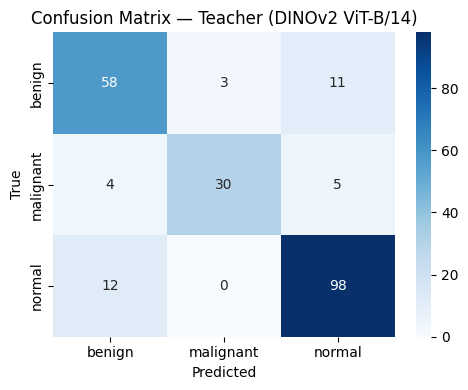

Teacher unloaded. VRAM freed for Phase 2 student baseline training.


In [13]:
ckpt = torch.load(CKPT_DIR / "best_teacher.pth", map_location=device)
teacher.load_state_dict(ckpt["state_dict"])
print(f"Loaded teacher epoch {ckpt['epoch']}  (val Dice={ckpt['dice']:.4f})")

# ── Test evaluation on shared fair-comparison loader ─────────────────────────
teacher_test_res, teacher_preds, teacher_labels = full_evaluate(
    teacher, ts_ld_eval, "Teacher (DINOv2 ViT-B/14)"
)

# ── Free teacher GPU memory — not needed until Phase 3 ──────────────────────
del teacher
gc.collect(); torch.cuda.empty_cache()
print(f"Teacher unloaded. VRAM freed for Phase 2 student baseline training.")


## 8. Phase 2 — Student Baseline Training
**EfficientNet-B0 + SMP UNet | ~7.5 M params**
Trained independently **without** any knowledge distillation — necessary to prove KD effectiveness.

In [14]:
print("=" * 65)
print("  PHASE 2 — STUDENT BASELINE  (MobileNetV2 + SMP UNet)")
print("=" * 65)

tr_ld_s, vl_ld_s, _, _, _, _ = make_loaders(
    SCFG["img_size"], SCFG["batch_size"], SCFG["num_workers"])

student_base = StudentDualTaskModel(
    SCFG["encoder_name"], SCFG["num_classes"], SCFG["img_size"],
    encoder_weights=SCFG["encoder_weights"]
).to(device)

n_student = sum(p.numel() for p in student_base.parameters()) / 1e6
print(f"Student params    : {n_student:.2f}M")
print(f"Compression ratio : {n_teacher/n_student:.1f}x")
print(f"Size ratio        : {n_teacher*4:.0f}MB -> {n_student*4:.0f}MB (FP32)")

student_base_hist, student_base_best_val_dice = run_training(
    student_base, tr_ld_s, vl_ld_s, SCFG, "best_student_base.pth", is_teacher=False
)


  PHASE 2 — STUDENT BASELINE  (MobileNetV2 + SMP UNet)
  train=1026 | valid=220 | test=221
Student params    : 7.95M
Compression ratio : 11.0x
Size ratio        : 350MB -> 32MB (FP32)


  Ep 001/60  tr_loss=1.8224 tr_dice=0.1544 tr_acc=0.6269 | vl_dice=0.2168 vl_acc=0.7545  checkpointed (dice=0.2168)  patience=0/12


  Ep 002/60  tr_loss=1.4644 tr_dice=0.2868 tr_acc=0.7154 | vl_dice=0.3446 vl_acc=0.7842  checkpointed (dice=0.3446)  patience=0/12


  Ep 003/60  tr_loss=1.3269 tr_dice=0.4199 tr_acc=0.7394 | vl_dice=0.5802 vl_acc=0.8051  checkpointed (dice=0.5802)  patience=0/12


  Ep 004/60  tr_loss=1.2077 tr_dice=0.5321 tr_acc=0.7808 | vl_dice=0.6497 vl_acc=0.8125  checkpointed (dice=0.6497)  patience=0/12


...

  Ep 035/60  tr_loss=0.3474 tr_dice=0.8393 tr_acc=0.9212 | vl_dice=0.8358 vl_acc=0.8378  patience=2/12


  Ep 037/60  tr_loss=0.3109 tr_dice=0.8685 tr_acc=0.9202 | vl_dice=0.8618 vl_acc=0.8482  checkpointed (dice=0.8618)  patience=0/12


  Ep 040/60  tr_loss=0.3061 tr_dice=0.8661 tr_acc=0.9385 | vl_dice=0.8350 vl_acc=0.8438  patience=3/12


  Ep 045/60  tr_loss=0.3268 tr_dice=0.8637 tr_acc=0.9115 | vl_dice=0.8562 vl_acc=0.8571  patience=8/12


  Early stopping triggered at epoch 49 (no improvement for 12 epochs)
  Early stopping: best weights restored (dice=0.8618)

  Done. Best val Dice=0.8618 | Total time=21.5 min


Loaded student baseline epoch 37  (val Dice=0.8618)



  Student Baseline (no KD)
  Dice        : 0.8348
  IoU         : 0.7926
  Acc         : 0.8145
  Macro F1    : 0.7926
  Seg Loss    : 0.3176
  Cls Loss    : 0.5427

  Classification Report:
              precision    recall  f1-score   support

      benign       0.79      0.74      0.76        72
   malignant       0.78      0.72      0.75        39
      normal       0.84      0.90      0.87       110

    accuracy                           0.81       221
   macro avg       0.80      0.78      0.79       221
weighted avg       0.81      0.81      0.81       221



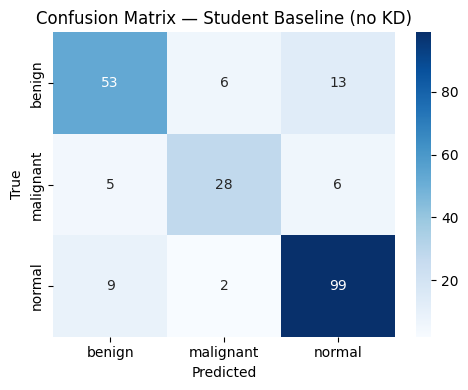

In [15]:
ckpt = torch.load(CKPT_DIR / "best_student_base.pth", map_location=device)
student_base.load_state_dict(ckpt["state_dict"])
print(f"Loaded student baseline epoch {ckpt['epoch']}  (val Dice={ckpt['dice']:.4f})")

student_base_test_res, sb_preds, sb_labels = full_evaluate(
    student_base, ts_ld_eval, "Student Baseline (no KD)"
)


## 9. Phase 3 — Multistage Knowledge Distillation (MSKD)
Teacher is **permanently frozen**. Student is re-initialised from scratch for a fair comparison.
The 4-stage curriculum progressively adds distillation objectives:
- Stage 1 (1–5): task loss only — stable warm-up
- Stage 2 (6–25): + soft classification labels (KL, T=4) + soft seg masks (MSE)
- Stage 3 (26–50): + cosine feature alignment between encoder bottleneck and patch tokens
- Stage 4 (51–60): task-dominant fine-tuning with reduced KD weights

In [16]:
print("=" * 65)
print("  PHASE 3 — MULTISTAGE KNOWLEDGE DISTILLATION (MSKD)")
print("=" * 65)

# ── Free student_base GPU memory before KD training ──────────────────────────
del student_base
gc.collect(); torch.cuda.empty_cache()
if torch.cuda.is_available():
    print(f"VRAM after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated")

# ── Reload teacher from checkpoint and freeze ────────────────────────────────
teacher = DINODualTaskModel(
    TCFG["dino_model"], TCFG["num_classes"], PATCH_GRID, TCFG["img_size"]
).to(device)
ckpt_t = torch.load(CKPT_DIR / "best_teacher.pth", map_location=device)
teacher.load_state_dict(ckpt_t["state_dict"])
teacher.eval()
for p in teacher.parameters(): p.requires_grad_(False)
print(f"Teacher reloaded from epoch {ckpt_t['epoch']} — frozen for MSKD.")

# ── Fresh student (random init — NOT loaded from baseline) ────────────────────
student_kd = StudentDualTaskModel(
    SCFG["encoder_name"], SCFG["num_classes"], SCFG["img_size"],
    encoder_weights=SCFG["encoder_weights"]
).to(device)

# FIX: differential LR — pretrained encoder gets a 5× smaller LR to
# preserve ImageNet features while heads and decoder learn fast
_enc_p  = list(student_kd.unet.encoder.parameters())
_head_p = [p for n, p in student_kd.named_parameters() if "unet.encoder" not in n]
opt_kd  = AdamW(
    [{"params": _enc_p,  "lr": SCFG["encoder_lr"]},
     {"params": _head_p, "lr": MCFG["lr"]}],
    weight_decay=MCFG["weight_decay"]
)
sch_kd = CosineAnnealingLR(opt_kd, T_max=MCFG["epochs"], eta_min=1e-7)

tr_ld_kd, vl_ld_kd, _, _, _, _ = make_loaders(
    SCFG["img_size"], MCFG["batch_size"], MCFG["num_workers"])

best_kd    = 0.0
kd_history = []
# Early stopping for MSKD — patience is per-stage aware:
# Stage 1 warm-up (5 ep) is excluded; patience resets at each stage transition
# to allow the model time to adapt to newly activated loss components.
es_kd       = EarlyStopping(patience=MCFG.get("patience", 10),
                             min_delta=1e-4, restore_best=True)
prev_stage  = 1

for epoch in range(1, MCFG["epochs"] + 1):
    tr, stage = train_mskd_epoch(student_kd, teacher, tr_ld_kd, opt_kd, MCFG, epoch)
    vl        = eval_one_epoch(student_kd, vl_ld_kd, SCFG["cls_weight"])
    sch_kd.step()

    row = {"epoch": epoch, "stage": stage,
           **{f"tr_{k}": v for k,v in tr.items()},
           **{f"vl_{k}": v for k,v in vl.items()}}
    kd_history.append(row)

    # Reset early stopping counter on stage transition — new losses need ramp-up time
    if stage != prev_stage:
        # Stage 3 gets extra patience: feature KD (feat_kd) takes several epochs
        # to stabilise after activation — premature stop killed Stage 3 last run
        stage_patience = 15 if stage == 3 else MCFG.get("patience", 12)
        es_kd = EarlyStopping(patience=stage_patience,
                               min_delta=1e-4, restore_best=True)
        print(f"  [Stage {stage}] Early stopping counter reset (patience={stage_patience})")
        prev_stage = stage

    flag = ""
    if vl["dice"] > best_kd:
        best_kd = vl["dice"]
        torch.save({"epoch": epoch, "state_dict": student_kd.state_dict(),
                    "dice": best_kd, "stage": stage},
                   CKPT_DIR / "best_student_kd.pth")
        flag = f"  checkpointed (dice={best_kd:.4f})"

    # Early stopping — skip Stage 1 warm-up (epochs 1-5)
    if stage > 1:
        es_kd.step(vl["dice"], student_kd)
        if es_kd.should_stop:
            print(f"  Early stopping triggered at epoch {epoch} Stage {stage} "
                  f"(no improvement for {es_kd.patience} epochs)")
            es_kd.restore(student_kd)
            break

    if epoch % 5 == 0 or flag:
        patience_used = 15 if stage == 3 else MCFG.get("patience", 12)
        print(f"  Ep {epoch:03d}/{MCFG['epochs']} [S{stage}]  "
              f"dice={tr['dice']:.4f} "
              f"cls_kd={tr['cls_kd']:.4f} seg_kd={tr['seg_kd']:.4f} feat_kd={tr['feat_kd']:.4f} | "
              f"vl_dice={vl['dice']:.4f} vl_acc={vl['acc']:.4f}{flag}"
              f"  patience={es_kd.counter}/{patience_used}")

kd_df = pd.DataFrame(kd_history)
print(f"\nMSKD complete. Best val Dice: {best_kd:.4f}")


  PHASE 3 — MULTISTAGE KNOWLEDGE DISTILLATION (MSKD)
VRAM after cleanup: 0.09 GB allocated


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Teacher reloaded from epoch 45 — frozen for MSKD.
  train=1026 | valid=220 | test=221


  Ep 001/80 [S1]  dice=0.1917 cls_kd=0.0000 seg_kd=0.0000 feat_kd=0.0000 | vl_dice=0.2284 vl_acc=0.6935  checkpointed (dice=0.2284)  patience=0/12


  Ep 002/80 [S1]  dice=0.4183 cls_kd=0.0000 seg_kd=0.0000 feat_kd=0.0000 | vl_dice=0.3175 vl_acc=0.7723  checkpointed (dice=0.3175)  patience=0/12


...

  Ep 054/80 [S4]  dice=0.8394 cls_kd=0.8033 seg_kd=0.0167 feat_kd=0.0748 | vl_dice=0.8432 vl_acc=0.8289  checkpointed (dice=0.8432)  patience=0/12


  Ep 055/80 [S4]  dice=0.8353 cls_kd=0.7209 seg_kd=0.0161 feat_kd=0.0726 | vl_dice=0.8282 vl_acc=0.8199  patience=1/12


  Ep 060/80 [S4]  dice=0.8549 cls_kd=0.6929 seg_kd=0.0159 feat_kd=0.0744 | vl_dice=0.8341 vl_acc=0.8333  patience=6/12


  Ep 065/80 [S4]  dice=0.8622 cls_kd=0.7115 seg_kd=0.0156 feat_kd=0.0729 | vl_dice=0.8220 vl_acc=0.8333  patience=11/12


  Early stopping triggered at epoch 66 Stage 4 (no improvement for 12 epochs)
  Early stopping: best weights restored (dice=0.8432)

MSKD complete. Best val Dice: 0.8432


Loaded MSKD student epoch 54 Stage 4  (val Dice=0.8432)



  Student + MSKD
  Dice        : 0.8242
  IoU         : 0.7792
  Acc         : 0.8371
  Macro F1    : 0.8268
  Seg Loss    : 0.3497
  Cls Loss    : 0.6432

  Classification Report:
              precision    recall  f1-score   support

      benign       0.80      0.74      0.77        72
   malignant       0.84      0.82      0.83        39
      normal       0.85      0.91      0.88       110

    accuracy                           0.84       221
   macro avg       0.83      0.82      0.83       221
weighted avg       0.84      0.84      0.84       221



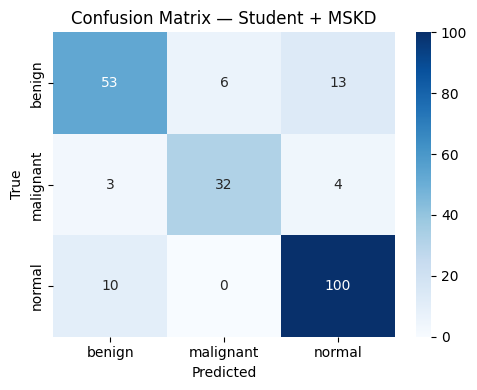

In [17]:
ckpt = torch.load(CKPT_DIR / "best_student_kd.pth", map_location=device)
student_kd.load_state_dict(ckpt["state_dict"])
print(f"Loaded MSKD student epoch {ckpt['epoch']} Stage {ckpt['stage']}"
      f"  (val Dice={ckpt['dice']:.4f})")

# Restore student_base from checkpoint for downstream visualisation
student_base = StudentDualTaskModel(
    SCFG["encoder_name"], SCFG["num_classes"], SCFG["img_size"],
    encoder_weights=SCFG["encoder_weights"]
).to(device)
ckpt_b = torch.load(CKPT_DIR / "best_student_base.pth", map_location=device)
student_base.load_state_dict(ckpt_b["state_dict"])

student_kd_test_res, kd_preds, kd_labels = full_evaluate(
    student_kd, ts_ld_eval, "Student + MSKD"
)


## 10. Results Comparison

In [18]:
comparison = pd.DataFrame({
    "Model":         ["Teacher (DINOv2)", "Student Baseline", "Student + MSKD"],
    "Params (M)":    [round(n_teacher,1), round(n_student,2), round(n_student,2)],
    "Compression":   ["1.0x",  f"{n_teacher/n_student:.1f}x", f"{n_teacher/n_student:.1f}x"],
    "Test Dice":     [teacher_test_res["Dice"],  student_base_test_res["Dice"],  student_kd_test_res["Dice"]],
    "Test IoU":      [teacher_test_res["IoU"],   student_base_test_res["IoU"],   student_kd_test_res["IoU"]],
    "Test Acc":      [teacher_test_res["Acc"],   student_base_test_res["Acc"],   student_kd_test_res["Acc"]],
    "Macro F1":      [teacher_test_res["Macro F1"], student_base_test_res["Macro F1"], student_kd_test_res["Macro F1"]],
    "Seg Loss":      [teacher_test_res["Seg Loss"], student_base_test_res["Seg Loss"], student_kd_test_res["Seg Loss"]],
    "Cls Loss":      [teacher_test_res["Cls Loss"], student_base_test_res["Cls Loss"], student_kd_test_res["Cls Loss"]],
})

print("\n" + "="*72); print("  FULL COMPARISON TABLE"); print("="*72)
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

d_gain = student_kd_test_res["Dice"]     - student_base_test_res["Dice"]
i_gain = student_kd_test_res["IoU"]      - student_base_test_res["IoU"]
a_gain = student_kd_test_res["Acc"]      - student_base_test_res["Acc"]
f_gain = student_kd_test_res["Macro F1"] - student_base_test_res["Macro F1"]
gap_t  = teacher_test_res["Dice"]        - student_kd_test_res["Dice"]

print(f"\n  KD Gain (MSKD vs Student Baseline):")
print(f"    Dice     : {d_gain:+.4f}")
print(f"    IoU      : {i_gain:+.4f}")
print(f"    Accuracy : {a_gain:+.4f}")
print(f"    Macro F1 : {f_gain:+.4f}")
print(f"\n  Teacher-Student Dice gap: {gap_t:.4f}  "
      f"({(1-gap_t/teacher_test_res['Dice'])*100:.1f}% of teacher Dice recovered"
      f" at {n_teacher/n_student:.1f}x compression)")



  FULL COMPARISON TABLE
           Model  Params (M) Compression  Test Dice  Test IoU  Test Acc  Macro F1  Seg Loss  Cls Loss
Teacher (DINOv2)     87.5000        1.0x     0.8737    0.8269    0.8416    0.8343    0.6462    0.7752
Student Baseline      7.9500       11.0x     0.8348    0.7926    0.8145    0.7926    0.3176    0.5427
  Student + MSKD      7.9500       11.0x     0.8242    0.7792    0.8371    0.8268    0.3497    0.6432

  KD Gain (MSKD vs Student Baseline):
    Dice     : -0.0107
    IoU      : -0.0134
    Accuracy : +0.0226
    Macro F1 : +0.0342

  Teacher-Student Dice gap: 0.0495  (94.3% of teacher Dice recovered at 11.0x compression)


## 11. Learning Curves

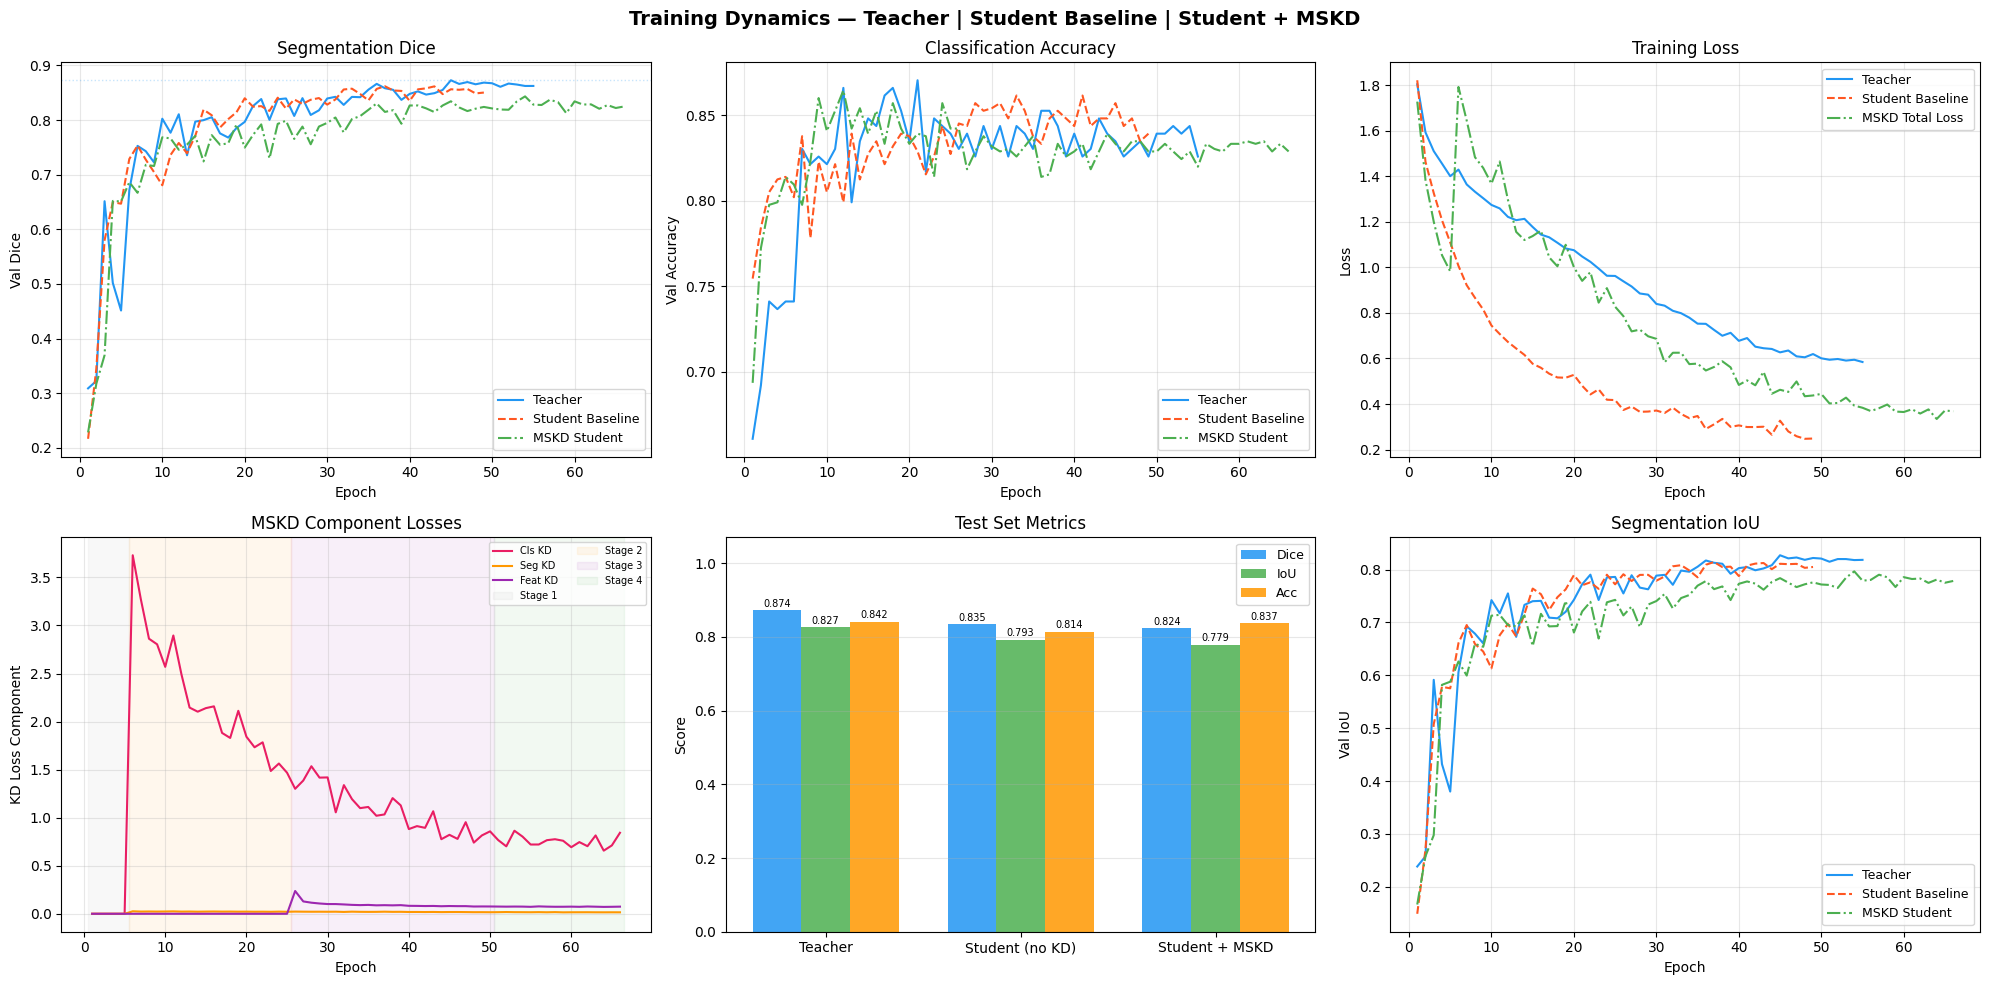

In [19]:
C = {"Teacher": "#2196F3", "Student Baseline": "#FF5722", "MSKD Student": "#4CAF50"}
LS = {"Teacher": "-",     "Student Baseline": "--",  "MSKD Student": "-."}
LABELS = list(C.keys())
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Training Dynamics — Teacher | Student Baseline | Student + MSKD",
             fontsize=14, fontweight="bold")

# ── Segmentation Dice ─────────────────────────────────────────────────────────
ax = axes[0,0]
for (hist, name) in [(teacher_hist,"Teacher"), (student_base_hist,"Student Baseline"),
                     (kd_df, "MSKD Student")]:
    col = "vl_dice"
    ax.plot(hist["epoch"], hist[col], color=C[name], ls=LS[name], label=name, lw=1.5)
ax.axhline(teacher_test_res["Dice"], color=C["Teacher"], alpha=0.25, lw=1, ls=":")
ax.set(xlabel="Epoch", ylabel="Val Dice", title="Segmentation Dice")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Classification Accuracy ───────────────────────────────────────────────────
ax = axes[0,1]
for (hist, name) in [(teacher_hist,"Teacher"), (student_base_hist,"Student Baseline"),
                     (kd_df, "MSKD Student")]:
    ax.plot(hist["epoch"], hist["vl_acc"], color=C[name], ls=LS[name], label=name, lw=1.5)
ax.set(xlabel="Epoch", ylabel="Val Accuracy", title="Classification Accuracy")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Training Loss ─────────────────────────────────────────────────────────────
ax = axes[0,2]
ax.plot(teacher_hist["epoch"],      teacher_hist["tr_loss"],      color=C["Teacher"],          ls=LS["Teacher"],          label="Teacher",          lw=1.5)
ax.plot(student_base_hist["epoch"], student_base_hist["tr_loss"], color=C["Student Baseline"], ls=LS["Student Baseline"], label="Student Baseline", lw=1.5)
ax.plot(kd_df["epoch"],             kd_df["tr_total"],            color=C["MSKD Student"],     ls=LS["MSKD Student"],     label="MSKD Total Loss",  lw=1.5)
ax.set(xlabel="Epoch", ylabel="Loss", title="Training Loss")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── MSKD Component Losses ─────────────────────────────────────────────────────
STAGE_C = {1:"#9E9E9E", 2:"#FF9800", 3:"#9C27B0", 4:"#4CAF50"}
ax = axes[1,0]
ax.plot(kd_df["epoch"], kd_df["tr_cls_kd"],  label="Cls KD",  color="#E91E63", lw=1.5)
ax.plot(kd_df["epoch"], kd_df["tr_seg_kd"],  label="Seg KD",  color="#FF9800", lw=1.5)
ax.plot(kd_df["epoch"], kd_df["tr_feat_kd"], label="Feat KD", color="#9C27B0", lw=1.5)
for s in [1,2,3,4]:
    sdf = kd_df[kd_df["stage"]==s]
    if not sdf.empty:
        ax.axvspan(sdf["epoch"].min()-0.5, sdf["epoch"].max()+0.5,
                   alpha=0.07, color=STAGE_C[s], label=f"Stage {s}")
ax.set(xlabel="Epoch", ylabel="KD Loss Component", title="MSKD Component Losses")
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

# ── Bar: Final Test Metrics ───────────────────────────────────────────────────
ax = axes[1,1]
# FIX: use string concatenation (not \n) so Python parses correctly
model_names = ["Teacher", "Student (no KD)", "Student + MSKD"]
dices = [teacher_test_res["Dice"],  student_base_test_res["Dice"],  student_kd_test_res["Dice"]]
ious  = [teacher_test_res["IoU"],   student_base_test_res["IoU"],   student_kd_test_res["IoU"]]
accs  = [teacher_test_res["Acc"],   student_base_test_res["Acc"],   student_kd_test_res["Acc"]]
xp = np.arange(3); w = 0.25
for i, (vals, lbl, clr) in enumerate([(dices,"Dice","#2196F3"),(ious,"IoU","#4CAF50"),(accs,"Acc","#FF9800")]):
    bars = ax.bar(xp + (i-1)*w, vals, w, label=lbl, color=clr, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+w/2, bar.get_height()+0.003,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)
ax.set(xticks=xp, xticklabels=model_names, ylabel="Score",
       title="Test Set Metrics", ylim=(0,1.07))
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="y")

# ── IoU Curves ────────────────────────────────────────────────────────────────
ax = axes[1,2]
for (hist, name) in [(teacher_hist,"Teacher"), (student_base_hist,"Student Baseline"),
                     (kd_df,"MSKD Student")]:
    ax.plot(hist["epoch"], hist["vl_iou"], color=C[name], ls=LS[name], label=name, lw=1.5)
ax.set(xlabel="Epoch", ylabel="Val IoU", title="Segmentation IoU")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Visual Predictions — Side-by-Side Comparison

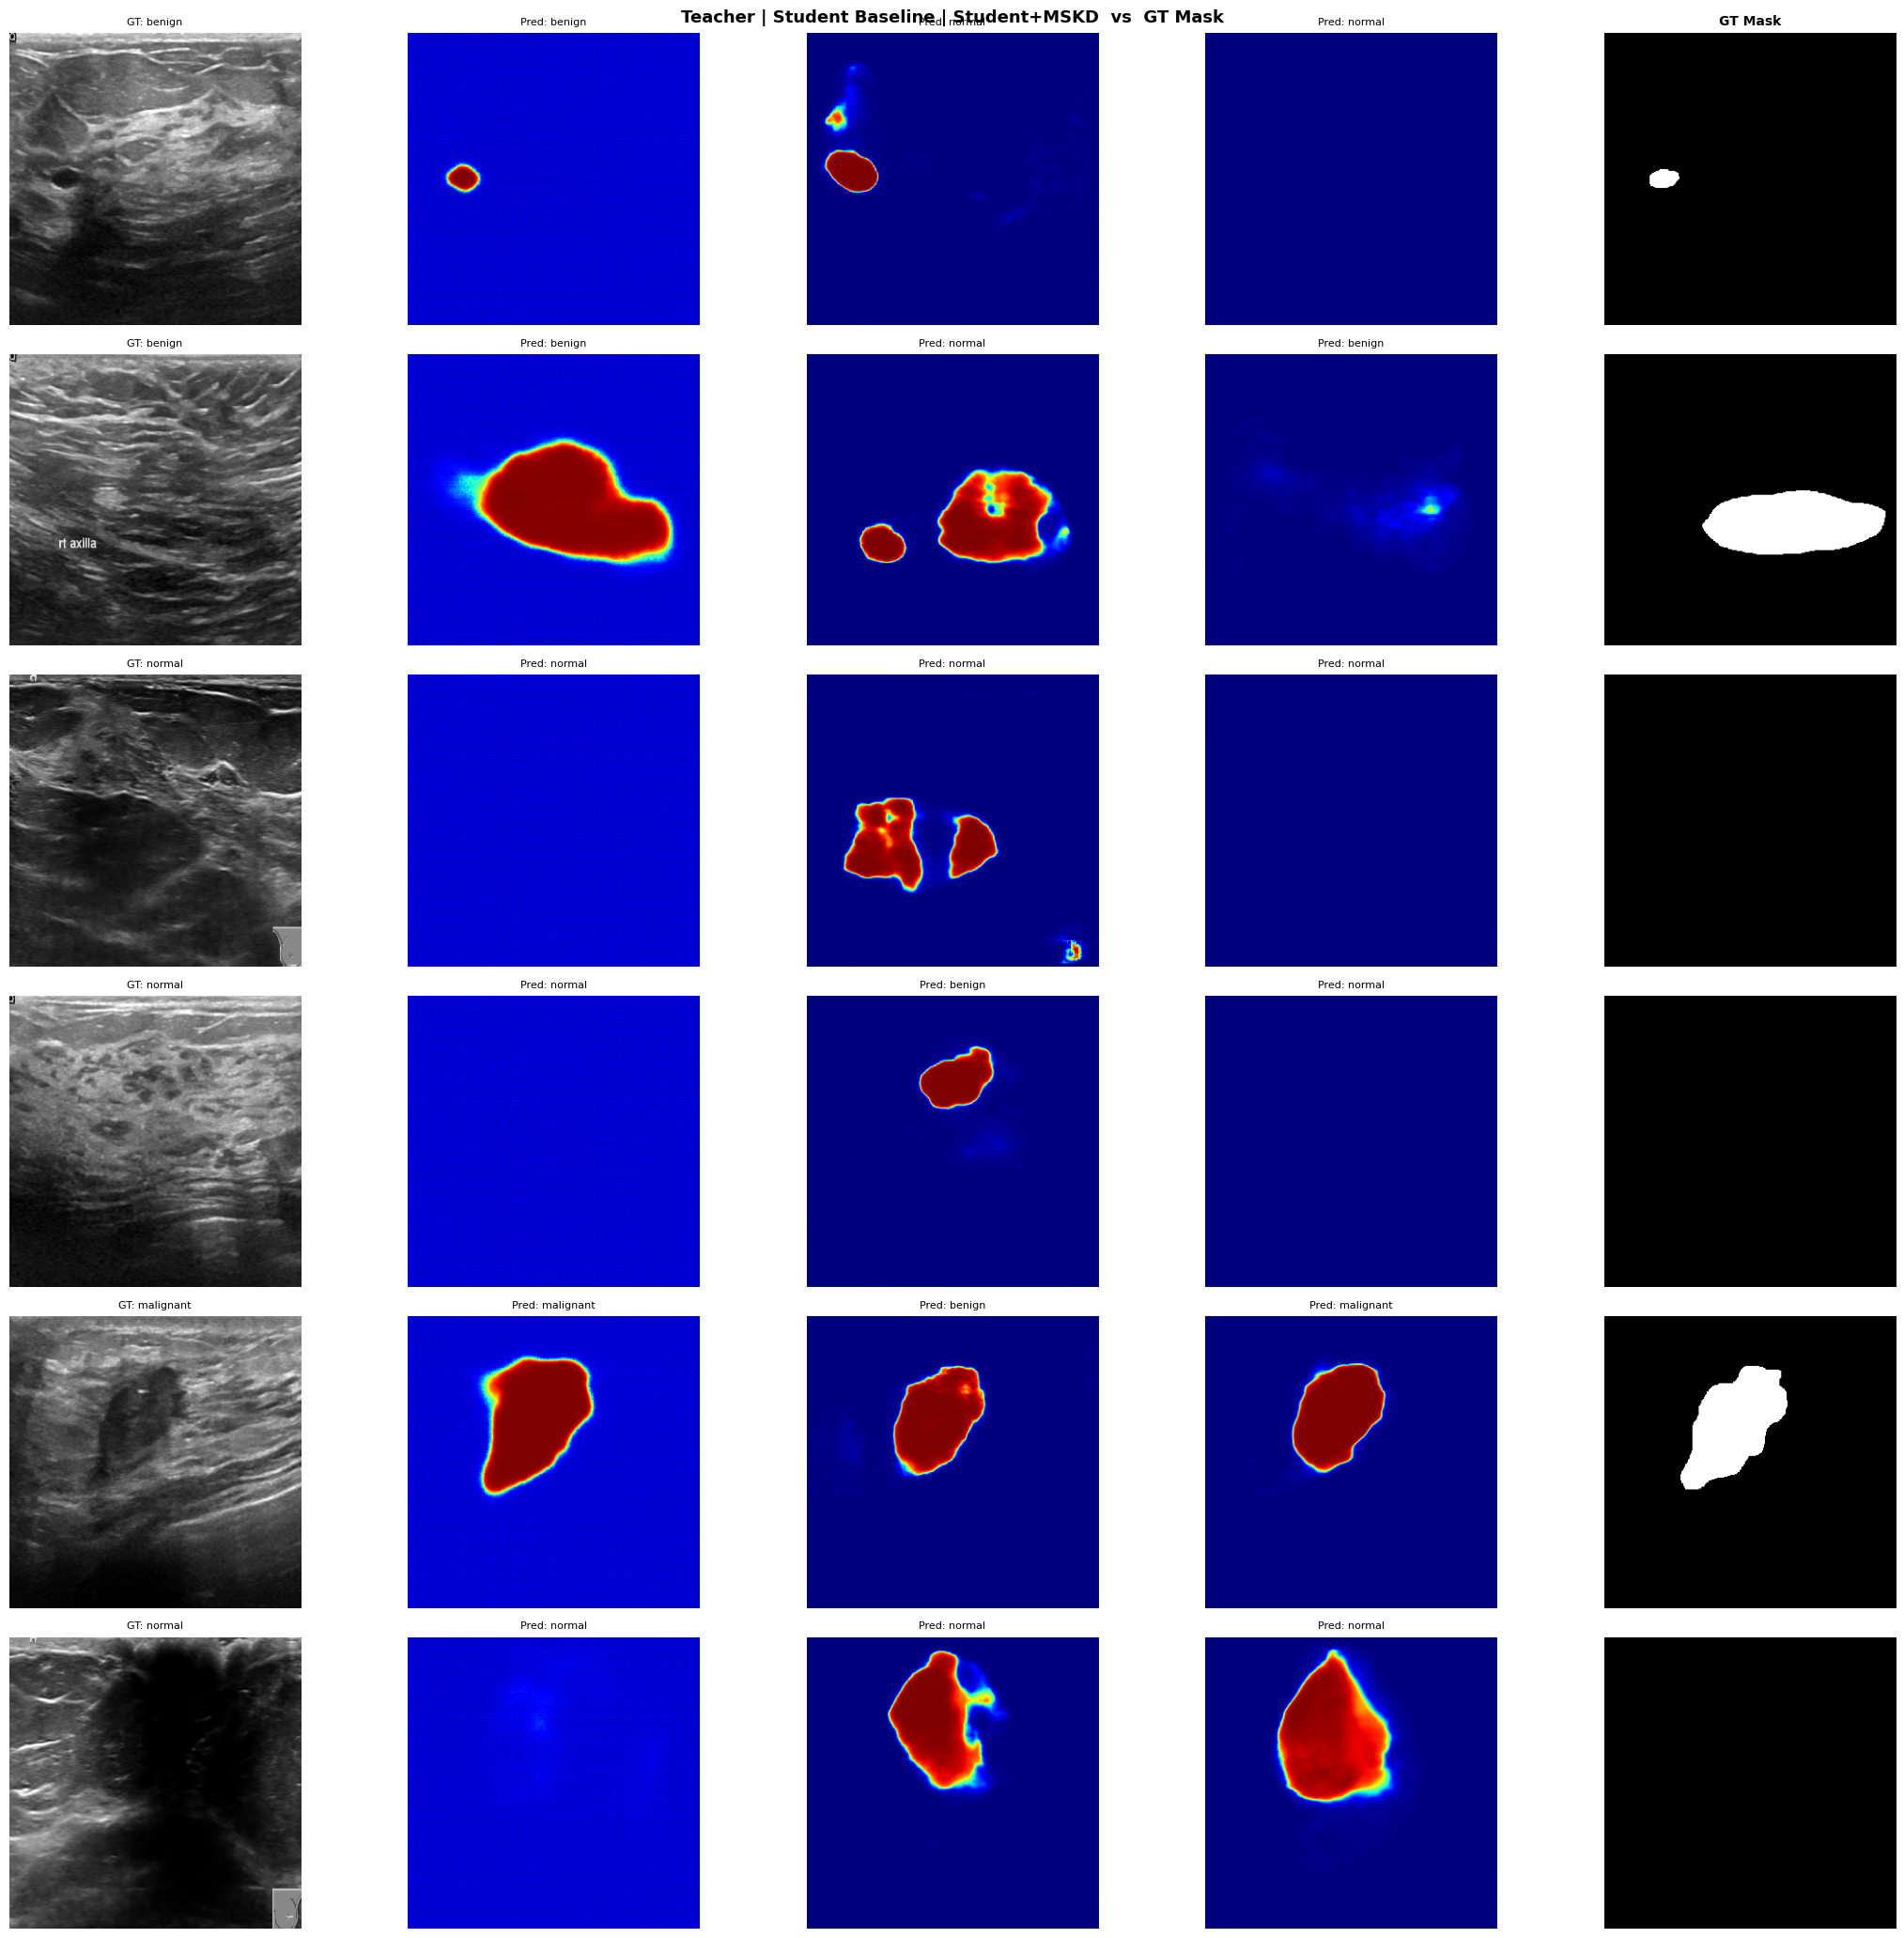

In [20]:
@torch.no_grad()
def predict(model, sample):
    img_t  = sample["image"].unsqueeze(0).to(device)
    seg, cls = model(img_t)
    pmask  = torch.sigmoid(seg)[0,0].cpu().numpy()
    plabel = IDX2LABEL[cls.argmax(1).item()]
    img_v  = (sample["image"].numpy().transpose(1,2,0) * IMGNET_STD + IMGNET_MEAN).clip(0,1)
    return img_v, sample["mask"][0].numpy(), pmask, sample["label"], plabel

N = 6
fig, axes = plt.subplots(N, 5, figsize=(22, N*3.5))
fig.suptitle("Teacher | Student Baseline | Student+MSKD  vs  GT Mask",
             fontsize=13, fontweight="bold")

for c, t in enumerate(["Image (GT label)","Teacher","Student Baseline","Student+MSKD","GT Mask"]):
    axes[0,c].set_title(t, fontsize=10, fontweight="bold")

for row in range(N):
    sample = ts_ds_eval[row]
    img_v, gtm = (sample["image"].numpy().transpose(1,2,0)*IMGNET_STD+IMGNET_MEAN).clip(0,1), sample["mask"][0].numpy()
    _, _, tm, gt_lbl, tp = predict(teacher,      sample)
    _, _, sm, _,      sp = predict(student_base, sample)
    _, _, km, _,      kp = predict(student_kd,   sample)

    axes[row,0].imshow(img_v[:,:,0], cmap="gray")
    axes[row,0].set_title(f"GT: {gt_lbl}", fontsize=8)
    for col, (mask, pred) in enumerate([(tm,tp),(sm,sp),(km,kp)], 1):
        axes[row,col].imshow(mask, cmap="jet", vmin=0, vmax=1)
        axes[row,col].set_title(f"Pred: {pred}", fontsize=8)
    axes[row,4].imshow(gtm, cmap="gray")
    for ax in axes[row]: ax.axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/visual_predictions.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Per-Class Analysis

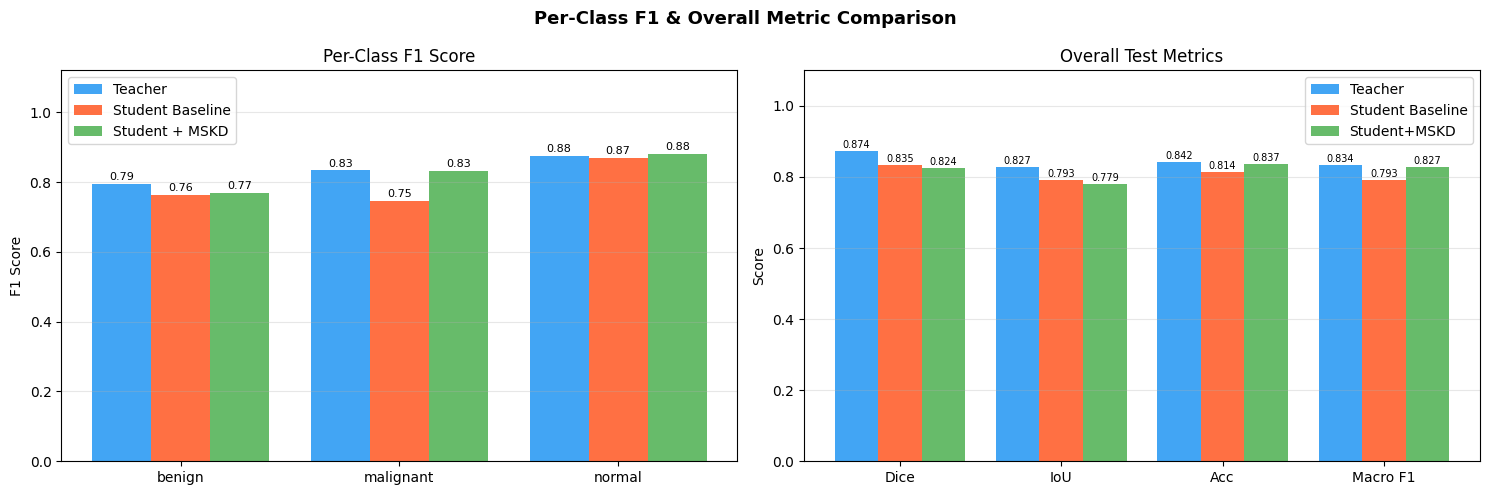


KD Gain per class (MSKD vs Student Baseline):
  benign      : +0.0055  (baseline=0.7626 -> kd=0.7681)
  malignant   : +0.0845  (baseline=0.7467 -> kd=0.8312)
  normal      : +0.0126  (baseline=0.8684 -> kd=0.8811)


In [21]:
def per_f1(true_labels, pred_labels, names=["benign","malignant","normal"]):
    return dict(zip(names, f1_score(true_labels, pred_labels, average=None, labels=[0,1,2])))

t_f1  = per_f1(teacher_labels, teacher_preds)
sb_f1 = per_f1(sb_labels,      sb_preds)
kd_f1 = per_f1(kd_labels,      kd_preds)
cls_n = ["benign","malignant","normal"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Per-Class F1 & Overall Metric Comparison", fontsize=13, fontweight="bold")

ax = axes[0]
xp = np.arange(len(cls_n)); w = 0.27
for i, (f1d, lbl, clr) in enumerate([(t_f1,"Teacher","#2196F3"),
                                      (sb_f1,"Student Baseline","#FF5722"),
                                      (kd_f1,"Student + MSKD","#4CAF50")]):
    bars = ax.bar(xp + (i-1)*w, [f1d[c] for c in cls_n], w, label=lbl, color=clr, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+w/2, bar.get_height()+0.005,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
ax.set(xticks=xp, xticklabels=cls_n, ylabel="F1 Score",
       title="Per-Class F1 Score", ylim=(0,1.12))
ax.legend(); ax.grid(alpha=0.3, axis="y")

ax = axes[1]
mets = ["Dice","IoU","Acc","Macro F1"]
tv   = [teacher_test_res[m] for m in mets]
bv   = [student_base_test_res[m] for m in mets]
kv   = [student_kd_test_res[m]   for m in mets]
xp2  = np.arange(len(mets))
for i, (vals, lbl, clr) in enumerate([(tv,"Teacher","#2196F3"),(bv,"Student Baseline","#FF5722"),(kv,"Student+MSKD","#4CAF50")]):
    bars = ax.bar(xp2 + (i-1)*w, vals, w, label=lbl, color=clr, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+w/2, bar.get_height()+0.003,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)
ax.set(xticks=xp2, xticklabels=mets, ylabel="Score",
       title="Overall Test Metrics", ylim=(0,1.1))
ax.legend(); ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("/kaggle/working/per_class_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKD Gain per class (MSKD vs Student Baseline):")
for c in cls_n:
    g = kd_f1[c] - sb_f1[c]
    print(f"  {c:<12}: {g:+.4f}  (baseline={sb_f1[c]:.4f} -> kd={kd_f1[c]:.4f})")


## 14. Final Summary & Export

In [22]:
import json

print("\n" + "="*65)
print("  FINAL SUMMARY — MULTISTAGE KNOWLEDGE DISTILLATION")
print("="*65)
print(f"  Teacher  (DINOv2 ViT-B/14)   : {n_teacher:.1f}M params")
print(f"  Student  (MobileNetV2)         : {n_student:.2f}M params")
print(f"  Compression                   : {n_teacher/n_student:.1f}x")
print()
print(f"  {'Metric':<10} {'Teacher':>10} {'Baseline':>12} {'MSKD':>10} {'KD Gain':>10}")
print(f"  {'-'*55}")
for met in ["Dice","IoU","Acc","Macro F1"]:
    tv = teacher_test_res[met]; bv = student_base_test_res[met]; kv = student_kd_test_res[met]
    print(f"  {met:<10} {tv:>10.4f} {bv:>12.4f} {kv:>10.4f} {kv-bv:>+10.4f}")

summary = {
    "teacher":          {"params_M": n_teacher, **teacher_test_res},
    "student_baseline": {"params_M": n_student, **student_base_test_res},
    "student_mskd":     {"params_M": n_student, **student_kd_test_res},
    "compression_x":    n_teacher / n_student,
    "kd_gain":          {k: student_kd_test_res[k]-student_base_test_res[k]
                         for k in ["Dice","IoU","Acc","Macro F1"]},
}
with open("/kaggle/working/results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n  Output files:")
for fn in ["training_curves.png","visual_predictions.png",
           "per_class_analysis.png","results_summary.json"]:
    p = Path("/kaggle/working") / fn
    size = p.stat().st_size // 1024 if p.exists() else 0
    print(f"    {'OK' if p.exists() else 'MISSING'} /kaggle/working/{fn}  ({size}KB)")
print("  Checkpoints: /kaggle/working/checkpoints/")



  FINAL SUMMARY — MULTISTAGE KNOWLEDGE DISTILLATION
  Teacher  (DINOv2 ViT-B/14)   : 87.5M params
  Student  (MobileNetV2)         : 7.95M params
  Compression                   : 11.0x

  Metric        Teacher     Baseline       MSKD    KD Gain
  -------------------------------------------------------
  Dice           0.8737       0.8348     0.8242    -0.0107
  IoU            0.8269       0.7926     0.7792    -0.0134
  Acc            0.8416       0.8145     0.8371    +0.0226
  Macro F1       0.8343       0.7926     0.8268    +0.0342

  Output files:
    OK /kaggle/working/training_curves.png  (423KB)
    OK /kaggle/working/visual_predictions.png  (2819KB)
    OK /kaggle/working/per_class_analysis.png  (76KB)
    OK /kaggle/working/results_summary.json  (0KB)
  Checkpoints: /kaggle/working/checkpoints/
